# DS-001: Customer Behavor Profiling & Data Audit

## Business Context

You have just joined an eCommerce analytics team.

The Product Manager sends you the following Slack message:

"We've accumulated several months of clickstream data, but nobody trusts it. Before we start building dashboards or analyzing user behavior, we need to understand what data we have, how clean it is, and whether there are any obvious quality issues."

You have one afternoon.

## Objective

Produce an exploratory analysis and data quality report for the clickstream dataset.

The goal is *not* to answer business questions yet.

The goal is to understand the data.

## Part 1 - load the data
1. Read both months
2. Combine into a single dataframe
   - Load efficiently
   - Watch memory usage
   - Check datatypes
   - Parse timestamps

We will load this dataset using the Pandas python package.  The data is located in `datasets/<filename>.csv.gz` for disk space efficiency.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#get a quick view of the dataset so that we have some idea of what we're looking at
!zcat datasets/2019-Oct.csv.gz | head
!zcat datasets/2019-Oct.csv.gz | wc -l
!zcat datasets/2019-Nov.csv.gz | wc -l

event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d
2019-10-01 00:00:05 UTC,view,1480613,2053013561092866779,computers.desktop,pulser,908.62,512742880,0d0d91c2-c9c2-4e81-90a5-86594dec0db9
2019-10-01 00:00:08 UTC,view,17300353,2053013553853497655,,creed,380.96,555447699,

Ok, so we have 42M rows for the October file and 67M rows for the November file.  For a quick initial load and file type checking, we will only hande the first 100 rows.

In [3]:
oct = pd.read_csv('datasets/2019-Oct.csv.gz', nrows=100)
oct.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [4]:
nov = pd.read_csv('datasets/2019-Nov.csv.gz', nrows=100)
nov.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:00 UTC,view,1003461,2053013555631882655,electronics.smartphone,xiaomi,489.07,520088904,4d3b30da-a5e4-49df-b1a8-ba5943f1dd33
1,2019-11-01 00:00:00 UTC,view,5000088,2053013566100866035,appliances.sewing_machine,janome,293.65,530496790,8e5f4f83-366c-4f70-860e-ca7417414283
2,2019-11-01 00:00:01 UTC,view,17302664,2053013553853497655,NaN,creed,28.31,561587266,755422e7-9040-477b-9bd2-6a6e8fd97387
3,2019-11-01 00:00:01 UTC,view,3601530,2053013563810775923,appliances.kitchen.washer,lg,712.87,518085591,3bfb58cd-7892-48cc-8020-2f17e6de6e7f
4,2019-11-01 00:00:01 UTC,view,1004775,2053013555631882655,electronics.smartphone,xiaomi,183.27,558856683,313628f1-68b8-460d-84f6-cec7a8796ef2


Looking at these two file, it looks like we have the following columns:
1. event_time: timestamp (to seconds)
2. event_type: string
3. product_id: int (probably use a bigint)
4. category_id: int (definitely use a bigint if not a numeric with 0 decimals)
5. category_code: string (heirarchical categorization)
6. brand: string
7. price: float (might want to store as numeric with 2 decimals)
8. user_id: int
9. user_session: This is a uuid - store as a string

In [5]:
oct.dtypes

event_time           str
event_type           str
product_id         int64
category_id        int64
category_code        str
brand                str
price            float64
user_id            int64
user_session         str
dtype: object

So pandas did a pretty good job autoselecting the column types.  We should just need to clean up the event_time column

In [6]:
oct['event_time'] = pd.to_datetime(oct.event_time, utc=True)
print(oct.head())
print(oct.dtypes)

                 event_time event_type  product_id          category_id  \
0 2019-10-01 00:00:00+00:00       view    44600062  2103807459595387724   
1 2019-10-01 00:00:00+00:00       view     3900821  2053013552326770905   
2 2019-10-01 00:00:01+00:00       view    17200506  2053013559792632471   
3 2019-10-01 00:00:01+00:00       view     1307067  2053013558920217191   
4 2019-10-01 00:00:04+00:00       view     1004237  2053013555631882655   

                         category_code     brand    price    user_id  \
0                                  NaN  shiseido    35.79  541312140   
1  appliances.environment.water_heater      aqua    33.20  554748717   
2           furniture.living_room.sofa       NaN   543.10  519107250   
3                   computers.notebook    lenovo   251.74  550050854   
4               electronics.smartphone     apple  1081.98  535871217   

                           user_session  
0  72d76fde-8bb3-4e00-8c23-a032dfed738c  
1  9333dfbd-b87a-4708-9857-63365

So now we have the first 100 rows.  Since we looked earlier, and it seems that the november file is similar, let's define a loader function that loads
in our data and processes the event_time column.

In [7]:
def data_load(filename: str, nrows:int=0) -> pd.DataFrame:
    if nrows > 0:
        df = pd.read_csv(filename, nrows=nrows)
    else:
        df = pd.read_csv(filename)
    df['event_time'] = pd.to_datetime(df.event_time, utc=True)
    return df

Now that we have our loader and it looks like all the data is in place, let's move on to step 2
## Part 2 — Dataset Profile

Produce a summary containing:

1. Number of rows
2. Number of columns
3. Column names
4. Datatypes
5. Memory usage
6. Duplicate rows
7. Duplicate events
8. Missing values by column
9. Cardinality of every categorical column

Numbers 1, 2, 3, 4, and 5 are covered by pandas' info command.  From the above, it doesn't look like 8 is covered for this large of a dataset without adjusting the command.  I'll need to look up the exact syntax for that one.  6 is easy to understand - that's all values in the rows are equal.  7 is a little vague - I'm not seeing any columns that would indicate a repeated event vs a repeated row, so we'll leave that one out.

In [8]:
oct_full = data_load('datasets/2019-Oct.csv.gz')

print("October 2019 data details:")
print(oct_full.info())

print("\n Null value counts")
print(oct_full.isna().sum())

print("\nDataset description:")
print(oct_full.describe(include='all'))

print("\nDuplicated rows")
print(oct_full[oct_full.duplicated()])

print("\nCardinality")
for c in ['product_id', 'category_id', 'category_code', 'brand', 'user_id', 'user_session']:
    print(c, len(oct_full[c].unique()))

October 2019 data details:
<class 'pandas.DataFrame'>
RangeIndex: 42448764 entries, 0 to 42448763
Data columns (total 9 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[us, UTC]
 1   event_type     str                
 2   product_id     int64              
 3   category_id    int64              
 4   category_code  str                
 5   brand          str                
 6   price          float64            
 7   user_id        int64              
 8   user_session   str                
dtypes: datetime64[us, UTC](1), float64(1), int64(3), str(4)
memory usage: 2.8 GB
None

 Null value counts
event_time              0
event_type              0
product_id              0
category_id             0
category_code    13515609
brand             6117080
price                   0
user_id                 0
user_session            2
dtype: int64

Dataset description:
                              event_time event_type   

We can summarize our results as follows:
The October 2019 dataset has 42,448,764 rows and 9 columns.  
| # |  Column    |     Dtype |  Missing values | Cardinality |           
|--- | ------       |  -----   |  -------------  | ----------- |     
| 0  | event_time   |  datetime64[us, UTC] | 0 | N/A |
| 1  | event_type   |  str   | 0 | 3 |             
| 2  | product_id   |  int64  | 0 | 166,794 |            
| 3  | category_id  |  int64  | 0 | 624 |            
| 4  | category_code|  str    | 13,515,609 | 127 |            
| 5  | brand        |  str    |  6,117,080  | 3445 |        
| 6  | price        |  float64 | 0 | N/A |
| 7  | user_id      |  int64   | 0 | 3,022,290 |          
| 8  | user_session |  str  | 2 | 9,244,422 |

 It uses 2.8 Gb of memory

 There are 30,228 duplicated rows

In [9]:
#Since event_type, category_id, category_code, and brand are relatively low cardinality comapred to the number of rows, we will convert these to categorical types
oct_full[['event_type', 'category_id', 'category_code', 'brand']] = oct_full[['event_type', 'category_id', 'category_code', 'brand']].apply(lambda x: x.astype('category'))

#also, since the price has a floor of 0 in our dataset and maxes out less than $10k, we will shrink it's datatype to the smallest possible
oct_full['price'] = pd.to_numeric(oct_full['price'], downcast='float')

oct_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 42448764 entries, 0 to 42448763
Data columns (total 9 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[us, UTC]
 1   event_type     category           
 2   product_id     int64              
 3   category_id    category           
 4   category_code  category           
 5   brand          category           
 6   price          float32            
 7   user_id        int64              
 8   user_session   str                
dtypes: category(4), datetime64[us, UTC](1), float32(1), int64(2), str(1)
memory usage: 1.7 GB


Those changes dropped the memory usage from 2.8Gb to 1.7Gb - roughly a 40% drop in memory usage.  We'll make sure we do the same for the November dataset if the distribution of values i similar

In [11]:
# repeat for the November dataset
nov_full = data_load('datasets/2019-Nov.csv.gz')
print(nov_full.info())

print("\n Null value counts")
print(nov_full.isna().sum())

print("\nDataset description:")
print(nov_full.describe(include='all'))

print("\nDuplicated rows")
print(nov_full[nov_full.duplicated()])

print("\nCardinality")
for c in ['product_id', 'category_id', 'category_code', 'brand', 'user_id', 'user_session']:
    print(c, len(nov_full[c].unique()))

<class 'pandas.DataFrame'>
RangeIndex: 67501979 entries, 0 to 67501978
Data columns (total 9 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[us, UTC]
 1   event_type     str                
 2   product_id     int64              
 3   category_id    int64              
 4   category_code  str                
 5   brand          str                
 6   price          float64            
 7   user_id        int64              
 8   user_session   str                
dtypes: datetime64[us, UTC](1), float64(1), int64(3), str(4)
memory usage: 4.5 GB
None

 Null value counts
event_time              0
event_type              0
product_id              0
category_id             0
category_code    21898171
brand             9224078
price                   0
user_id                 0
user_session           10
dtype: int64

Dataset description:
                              event_time event_type    product_id  \
count       

We can summarize our results as follows:
The November 2019 dataset has 67,501,979 rows and 9 columns.  
| # |  Column    |     Dtype |  Missing values | Cardinality |           
|--- | ------       |  -----   |  -------------  | ----------- |     
| 0  | event_time   |  datetime64[us, UTC] | 0 | N/A |
| 1  | event_type   |  str   | 0 | 3 |             
| 2  | product_id   |  int64  | 0 | 190,662 |            
| 3  | category_id  |  int64  | 0 | 684 |            
| 4  | category_code|  str    | 21,898,171 | 130 |            
| 5  | brand        |  str    |  9,224,078  | 4201 |        
| 6  | price        |  float64 | 0 | N/A |
| 7  | user_id      |  int64   | 0 | 3,696,117 |          
| 8  | user_session |  str  | 10 | 13,776,051 |

 It uses 4.5 Gb of memory

 There are 100,519 duplicated rows

In [12]:
#Since event_type, category_id, category_code, and brand are relatively low cardinality comapred to the number of rows, we will convert these to categorical types
nov_full[['event_type', 'category_id', 'category_code', 'brand']] = nov_full[['event_type', 'category_id', 'category_code', 'brand']].apply(lambda x: x.astype('category'))

#also, since the price has a floor of 0 in our dataset and maxes out less than $10k, we will shrink it's datatype to the smallest possible
nov_full['price'] = pd.to_numeric(nov_full['price'], downcast='float')

nov_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 67501979 entries, 0 to 67501978
Data columns (total 9 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[us, UTC]
 1   event_type     category           
 2   product_id     int64              
 3   category_id    category           
 4   category_code  category           
 5   brand          category           
 6   price          float32            
 7   user_id        int64              
 8   user_session   str                
dtypes: category(4), datetime64[us, UTC](1), float32(1), int64(2), str(1)
memory usage: 2.7 GB


That dropped us from 4.5Gb memory used to 2.7Gb memory used.  Another 40% memory reduction.

In [13]:
#for simplicity going forward, let's drop the duplicate rows
oct_full = oct_full.drop_duplicates()
nov_full = nov_full.drop_duplicates()

## Part 3 - Data Quality Checks
We will use this section to check various data quality measures.  

Looking at our date/time ranges, we see that the timestamps covered in these files do match the monthly breaks expected (from above info analysis)
We will now check the distribution of dates and hours - looking to see if there are any patterns throughout the day or patterns throughout the month

In [17]:
df = pd.concat([oct_full, nov_full])
df['date'] = df['event_time'].dt.date
df['hour'] = df['event_time'].dt.hour
df['dow'] = df['event_time'].dt.dayofweek

In [18]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,date,hour,dow
0,2019-10-01 00:00:00+00:00,view,44600062,2103807459595387724,NaN,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c,2019-10-01,0,1
1,2019-10-01 00:00:00+00:00,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc,2019-10-01,0,1
2,2019-10-01 00:00:01+00:00,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8,2019-10-01,0,1
3,2019-10-01 00:00:01+00:00,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713,2019-10-01,0,1
4,2019-10-01 00:00:04+00:00,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d,2019-10-01,0,1


In [58]:
date_counts = df.groupby(['date', 'event_type'])['product_id'].count().reset_index()
hour_counts = df.groupby(['hour', 'event_type'])['product_id'].count().reset_index()
dow_counts = df.groupby(['dow', 'event_type'])['product_id'].count().reset_index()

/tmp/ipykernel_13762/3342114111.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


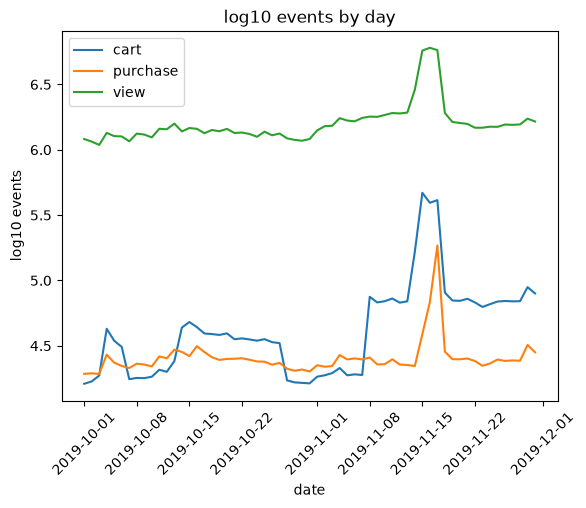

In [59]:
fig = plt.figure()
for event_type in ['cart', 'purchase', 'view']:
    plt.plot(date_counts.loc[date_counts.event_type==event_type,'date'], np.log10(date_counts.loc[date_counts.event_type==event_type,'product_id']), label=event_type)
plt.title('log10 events by day')
plt.xticks(rotation=45)
plt.xlabel('date')
plt.ylabel('log10 events')
plt.legend()
fig.show()

/tmp/ipykernel_13762/3227024499.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


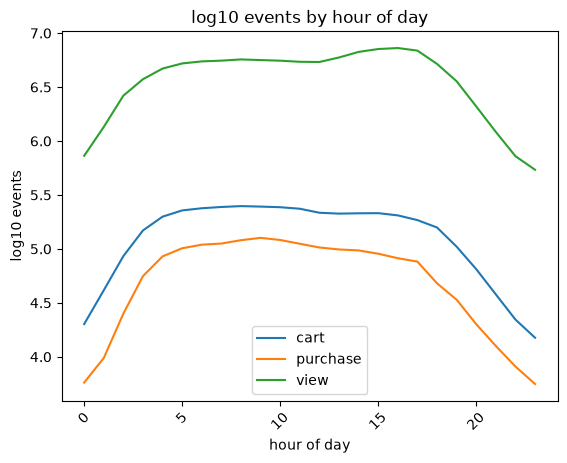

In [61]:
fig = plt.figure()
for event_type in ['cart', 'purchase', 'view']:
    plt.plot(hour_counts.loc[hour_counts.event_type==event_type,'hour'], np.log10(hour_counts.loc[hour_counts.event_type==event_type,'product_id']), label=event_type)
plt.title('log10 events by hour of day')
plt.xticks(rotation=45)
plt.xlabel('hour of day')
plt.ylabel('log10 events')
plt.legend()
fig.show()

/tmp/ipykernel_13762/1078974442.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


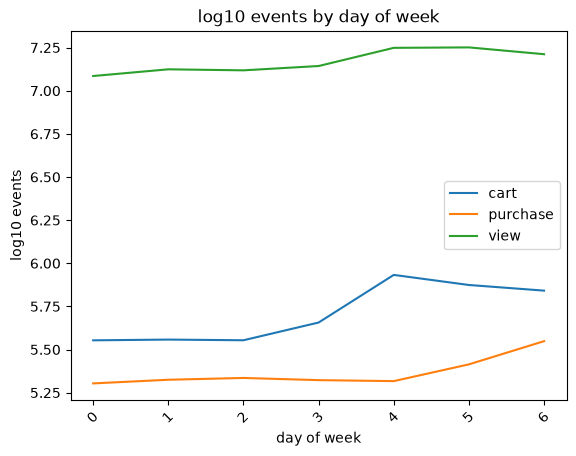

In [63]:
fig = plt.figure()
for event_type in ['cart', 'purchase', 'view']:
    plt.plot(dow_counts.loc[dow_counts.event_type==event_type,'dow'], np.log10(dow_counts.loc[dow_counts.event_type==event_type,'product_id']), label=event_type)
plt.title('log10 events by day of week')
plt.xticks(rotation=45)
plt.xlabel('day of week')
plt.ylabel('log10 events')
plt.legend()
fig.show()

The above results show us that there seems to be a daily pattern in number all three event types (high point around 14:00-18:00 UTC and low between 21:00-02:00 UTC.

The date plot has an interesting spike in values from the 14th through the 18th of November - possibly a pre-Black Friday sale?

Looking at this by day of week, there does appear to be some seasonality, where there is an increase in purchases toward the end of the week (Friday, Saturday, Sunday)

Now let's look at the distribution of missing values

In [74]:
df['category_missing'] = df['category_code'].isnull().astype(int)
df['brand_missing'] = df['brand'].isnull().astype(int)

In [75]:
df[['event_time', 'product_id', 'category_id', 'price', 'category_missing', 'brand_missing']].corr()

,event_time,product_id,category_id,price,category_missing,brand_missing
event_time,1.000000,0.076848,0.016996,-0.002045,0.003894,-0.010822
product_id,0.076848,1.000000,0.449989,-0.195666,0.400652,0.282337
category_id,0.016996,0.449989,1.000000,-0.045775,0.072467,0.074659
price,-0.002045,-0.195666,-0.045775,1.000000,-0.216098,-0.097851
category_missing,0.003894,0.400652,0.072467,-0.216098,1.000000,0.253456
brand_missing,-0.010822,0.282337,0.074659,-0.097851,0.253456,1.000000


In [78]:
df.groupby(['product_id', 'category_missing']).count()

,,event_time,event_type,category_id,category_code,brand,price,user_id,user_session,date,hour,dow,brand_missing
product_id,category_missing,,,,,,,,,,,,
1000365,0,1,1,1,1,1,1,1,1,1,1,1,1
1000978,0,10500,10500,10500,10500,10429,10500,10500,10500,10500,10500,10500,10500
1001588,0,4013,4013,4013,4013,4013,4013,4013,4013,4013,4013,4013,4013
1001606,0,31,31,31,31,31,31,31,31,31,31,31,31
1001618,0,1604,1604,1604,1604,1425,1604,1604,1604,1604,1604,1604,1604
...,...,...,...,...,...,...,...,...,...,...,...,...,...
100028525,1,10,10,10,0,0,10,10,10,10,10,10,10
100028530,0,1,1,1,1,0,1,1,1,1,1,1,1
100028536,1,1,1,1,0,0,1,1,1,1,1,1,1


Executive Summary:

This dataset covers two months worth of data of ecommerce events from our company, including product views, product additions to the cart, and product purchases.

This site covers approximately 167k products spread over around 680 category ids and 130 categories.  This is a little bit suspect and might require further analysis.

We see clear weekly seasonality in the data, which is expected due to purchasers having more time to browse our site over the weekends.  We also see a large bump in site traffic in mid-November, which is likely due to a pre-Black Friday sale.

The category_code and brand fields have a tendency to be missing (33% and 14%, respectively) over these two months of data, and based on very preliminary analysis, it appears that the missing values are linked with specific products and brands.

The prices given range from 0 to around 2500 - it's possible that the 0 values are representative of missing data, but that has not been investigated in this analysis due to lack of time.

We don't have information in this dataset about logged-in vs anonymous users.

Additional time to analyze the data would allow us to potentially see the ability for users to work through the conversion funnel from viewing, adding to cart, and purchasing within a single session and what our overall conversion rate is for different brands.
